#
# **Project Title: Retail Intelligence: A Data-Driven Study of Product Attributes & Sales Performance in E-commerce**

**Objective** :

* To identify which physical attributes (Material, Style, Price) drive high sales volume in the e-commerce sector.
* To determine if Customer Ratings and System Recommendations significantly contribute to an increase in sales.
* To identify which types of fabric materials perform best during different seasons and evaluate if a seasonal sales strategy is effective for the business.

**Dataset Overview** :

The analysis is based on two primary datasets containing information on retail dress inventory and performance:

* Attribute Dataset: Contains categorical and descriptive features for 500 unique dress designs.

  Key Features: Style, Price, Rating, Size, Season, NeckLine, SleeveLength, and Material composition.

  Purpose: To define the physical characteristics and market positioning of each product.

* Dress Sales Dataset: A time-series dataset tracking the sales volume for each Dress_ID across 23 specific dates in 2013.

  Key Features: Daily sales counts per item.

  Purpose: To provide the raw performance metrics needed to calculate total sales velocity and identify trends.
        

These datasets are linked via a common unique identifier, Dress_ID. To perform the analysis, the time-series sales data was aggregated into a single Total_Sales metric and merged with the attribute data to create a comprehensive "Retail Intelligence" master file.                                                                                                                                                                                                                                                                               
#
#



Importing Libraries

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
import warnings
warnings.simplefilter('ignore', FutureWarning)

Dataset loading

In [ ]:
attr_data = pd.read_excel('/content/Attribute DataSet.xlsx')
sales_data = pd.read_excel('/content/Dress Sales.xlsx')


Finding the rows and columns in datasets

In [ ]:
print(attr_data.shape)
print(sales_data.shape)

(500, 14)
(500, 24)


* Attribute dataset - 500 rows and 14 columns        
* Dress Sales dataset - 500 rows and 24 rows

Loading first 10 data of Attribute dataset

In [ ]:
attr_data.head(10)

,Dress_ID,Style,Price,Rating,Size,Season,NeckLine,SleeveLength,waiseline,Material,FabricType,Decoration,Pattern Type,Recommendation
0,1006032852,Sexy,Low,4.6,M,Summer,o-neck,sleevless,empire,NaN,chiffon,ruffles,animal,1
1,1212192089,Casual,Low,0.0,L,Summer,o-neck,Petal,natural,microfiber,NaN,ruffles,animal,0
2,1190380701,vintage,High,0.0,L,Automn,o-neck,full,natural,polyster,NaN,NaN,print,0
3,966005983,Brief,Average,4.6,L,Spring,o-neck,full,natural,silk,chiffon,embroidary,print,1
4,876339541,cute,Low,4.5,M,Summer,o-neck,butterfly,natural,chiffonfabric,chiffon,bow,dot,0
5,1068332458,bohemian,Low,0.0,M,Summer,v-neck,sleevless,empire,NaN,NaN,NaN,print,0
6,1220707172,Casual,Average,0.0,XL,Summer,o-neck,full,NaN,cotton,NaN,NaN,solid,0
7,1219677488,Novelty,Average,0.0,free,Automn,o-neck,short,natural,polyster,broadcloth,lace,NaN,0
8,1113094204,Flare,Average,0.0,free,Spring,v-neck,short,empire,cotton,broadcloth,beading,solid,1
9,985292672,bohemian,Low,0.0,free,Summer,v-neck,sleevless,natural,nylon,chiffon,NaN,NaN,1


Summary of Attribute sataset

In [ ]:
attr_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Dress_ID        500 non-null    int64  
 1   Style           500 non-null    object 
 2   Price           498 non-null    object 
 3   Rating          500 non-null    float64
 4   Size            500 non-null    object 
 5   Season          498 non-null    object 
 6   NeckLine        497 non-null    object 
 7   SleeveLength    498 non-null    object 
 8   waiseline       413 non-null    object 
 9   Material        372 non-null    object 
 10  FabricType      234 non-null    object 
 11  Decoration      264 non-null    object 
 12  Pattern Type    391 non-null    object 
 13  Recommendation  500 non-null    int64  
dtypes: float64(1), int64(2), object(11)
memory usage: 54.8+ KB


Statistical summary of Attribute Dataset

In [ ]:
attr_data.describe()

,Dress_ID,Rating,Recommendation
count,5.000000e+02,500.000000,500.000000
mean,9.055417e+08,3.528600,0.420000
std,1.736190e+08,2.005364,0.494053
min,4.442820e+08,0.000000,0.000000
25%,7.673164e+08,3.700000,0.000000
50%,9.083296e+08,4.600000,0.000000
75%,1.039534e+09,4.800000,1.000000
max,1.253973e+09,5.000000,1.000000


Data types of each attributes in Attribute Dataset

In [ ]:
attr_data.dtypes

,0
Dress_ID,int64
Style,object
Price,object
Rating,float64
Size,object
Season,object
NeckLine,object
SleeveLength,object
waiseline,object
Material,object


## Data Cleaning Summary

**Attribute Dataset (`attr_data`):**
- **Price:** Standardized 'Low', 'High', 'Average', 'Medium', 'Very High'. Nulls filled with mode ('Average').
- **Season:** Standardized 'Summer', 'Autumn', 'Spring', 'Winter'. Nulls filled with mode ('Summer').
- **NeckLine:** Standardized various necklines and capitalized. Nulls filled with mode ('O-neck').
- **SleeveLength:** Standardized various sleeve length terms (e.g., 'sleeveless', 'three quarter') and capitalized. Nulls filled with mode ('Sleeveless').
- **Waiseline:** Column name corrected to 'Waiseline'. Nulls filled with mode ('natural').
- **Material, FabricType, Decoration, Pattern Type:** Null values in these columns were replaced with 'Unknown'. Additionally, values within these columns were standardized and grouped (e.g., 'Leopard' merged into 'Animal' in 'Pattern Type').
- **Style:** Standardized 'Office Lady' and capitalized.
- **Size:** Standardized 'S' and 'Free'.
- **Duplicates:** One duplicate row was identified and removed.

**Dress Sales Dataset (`sales_data`):**
- **Column Names:** Date columns were converted to a standard `YYYY-MM-DD` format.
- **Data Types:** All sales columns were converted to numeric types, and any non-numeric values or nulls were coerced to 0 and then converted to integers.
- **Total_Sales:** A new column `Total_Sales` was created by summing sales across all date columns for each `Dress_ID`.

**Merged Dataset (`final_data`):**
- The `attr_data` and `sales_data` (specifically the `Dress_ID` and `Total_Sales` columns) were merged on `Dress_ID` using an inner join, creating a comprehensive `final_data` dataframe for further analysis. The final dataset has 548 rows and 15 columns.

### Data Cleaning - Attribute Dataset


Null values in each column

In [ ]:
attr_data.isnull().sum()

,0
Dress_ID,0
Style,0
Price,2
Rating,0
Size,0
Season,2
NeckLine,3
SleeveLength,2
waiseline,87
Material,128


Total null values in Attribute Dataset

In [ ]:
print('Total null values in Attribute Dataset:', attr_data.isnull().sum().sum())

Total null values in Attribute Dataset: 835


Total no. of duplicates in Attribute Dataset

In [ ]:
print('Total no. of duplicated items:', attr_data.duplicated().sum())

Total no. of duplicated items: 0


Data cleaning of `Price` column

In [ ]:
print('Unique items:', attr_data['Price'].unique())

Unique items: ['Low' 'High' 'Average' 'Medium' 'very-high' 'low' 'high' nan]


In [ ]:
attr_data['Price'] = attr_data['Price'].str.capitalize()
attr_data['Price'] = attr_data['Price'].replace('Very-high', 'Very High')
print(attr_data['Price'].unique())

['Low' 'High' 'Average' 'Medium' 'Very High' nan]


In [ ]:
attr_data['Price'].mode()

,Price
0,Average


In [ ]:
# Removing null values by replacing it using mode value

mod = attr_data['Price'].mode()
attr_data['Price'].fillna(mod.mode()[0], inplace=True)

In [ ]:
print(attr_data['Price'].isnull().sum())

0


* Found the unique items
* Replaced each item by capitalizing and correcting the spelling mistakes
* Filled NaN using mode
* Again checked the null values are removed or not for Price column

Data cleaning of `Season` column

In [ ]:
print('Unique items:', attr_data['Season'].unique())

Unique items: ['Summer' 'Automn' 'Spring' 'Winter' 'spring' 'winter' nan 'summer'
 'Autumn']


In [ ]:
attr_data['Season'] = attr_data['Season'].str.capitalize()
print(attr_data['Season'].unique())

['Summer' 'Automn' 'Spring' 'Winter' nan 'Autumn']


In [ ]:
attr_data['Season'] = attr_data['Season'].replace('Automn', 'Autumn')
print(attr_data['Season'].unique())

['Summer' 'Autumn' 'Spring' 'Winter' nan]


In [ ]:
season_mod = attr_data['Season'].mode()
attr_data['Season'].fillna(season_mod.mode()[0], inplace=True)

In [ ]:
print(attr_data['Season'].isnull().sum())

0


* Found the unique items
* Replaced each item by capitalizing and correcting the spelling mistakes
* Filled NaN using mode
* Again checked the null values are removed or not for Season column

Data cleaning of `Neckline` column

In [ ]:
print('Unique items:', attr_data['NeckLine'].unique())

Unique items: ['o-neck' 'v-neck' 'boat-neck' 'peterpan-collor' 'ruffled'
 'turndowncollor' 'slash-neck' 'mandarin-collor' 'open' 'sqare-collor'
 'Sweetheart' 'sweetheart' nan 'Scoop' 'halter' 'backless' 'bowneck']


In [ ]:
attr_data['NeckLine'] = attr_data['NeckLine'].str.capitalize()
print(attr_data['NeckLine'].unique())

['O-neck' 'V-neck' 'Boat-neck' 'Peterpan-collor' 'Ruffled'
 'Turndowncollor' 'Slash-neck' 'Mandarin-collor' 'Open' 'Sqare-collor'
 'Sweetheart' nan 'Scoop' 'Halter' 'Backless' 'Bowneck']


In [ ]:
neckline_mod = attr_data['NeckLine'].mode()[0]
attr_data['NeckLine'].fillna(neckline_mod, inplace=True)

print(attr_data['NeckLine'].isnull().sum())

0


* Found the unique items
* Replaced each item by capitalizing and correcting the spelling mistakes
* Filled NaN using mode
* Again checked the null values are removed or not for NeckLine column

Data cleaning of `SleeveLength` column

In [ ]:
print(attr_data['SleeveLength'].unique())

['sleevless' 'Petal' 'full' 'butterfly' 'short' 'threequarter'
 'halfsleeve' 'cap-sleeves' 'turndowncollor' 'threequater' 'capsleeves'
 'sleeveless' 'sleeevless' 'half' 'urndowncollor' 'thressqatar' nan
 'sleveless']


In [ ]:
attr_data['SleeveLength'] = attr_data['SleeveLength'].str.lower()
attr_data['SleeveLength'] = attr_data['SleeveLength'].replace(['sleevless','sleeevless', 'sleveless'], 'sleeveless')
attr_data['SleeveLength'] = attr_data['SleeveLength'].replace(['threequarter', 'threequater', 'thressqatar'], 'three quarter')
attr_data['SleeveLength'] = attr_data['SleeveLength'].replace(['halfsleeve', 'half'],'half sleeve')
attr_data['SleeveLength'] = attr_data['SleeveLength'].replace(['cap-sleeves', 'capsleeves'], 'cap sleeves')
attr_data['SleeveLength'] = attr_data['SleeveLength'].replace(['turndowncollor', 'urndowncollor'], 'turndown collar')

In [ ]:
attr_data['SleeveLength'] = attr_data['SleeveLength'].str.capitalize()
print(attr_data['SleeveLength'].unique())

['Sleeveless' 'Petal' 'Full' 'Butterfly' 'Short' 'Three quarter'
 'Half sleeve' 'Cap sleeves' 'Turndown collar' nan]


In [ ]:
sleeve_mod = attr_data['SleeveLength'].mode()[0]
attr_data['SleeveLength'].fillna(sleeve_mod, inplace=True)

print(attr_data['SleeveLength'].isnull().sum())

0


* Found the unique items
* Replaced each item by capitalizing and correcting the spelling mistakes
* Filled NaN using mode
* Again checked the null values are removed or not for SleeveLength column

Data cleaning of `Waiseline` column

In [ ]:
attr_data.rename(columns={'waiseline': 'Waiseline'}, inplace=True)  #Capitalizing column name
attr_data['Waiseline'] = attr_data['Waiseline'].str.capitalize()
print(attr_data['Waiseline'].unique())


['Empire' 'Natural' nan 'Princess' 'Dropped']


In [ ]:
attr_data['Waiseline'].isnull().sum()

np.int64(87)

In [ ]:
waiseline_mod = attr_data['Waiseline'].mode()[0]
attr_data['Waiseline'].fillna(waiseline_mod, inplace=True)

print(attr_data['Waiseline'].unique())
print(attr_data['Waiseline'].isnull().sum())

['Empire' 'Natural' 'Princess' 'Dropped']
0


* Capitalized column name and items in column
* Found the unique items
* Checked the no. of  null values present in Waiseline column
* Filled NaN using mode
* Again checked the null values are removed or not for Price column

Total null values in columns: `Material`,`FabricType`, `Decoration`, `Pattern Type`

In [ ]:
print('Null values in Material column:', attr_data['Material'].isnull().sum())
print('Null values in FabricType column:', attr_data['FabricType'].isnull().sum())
print('Null values in Decoration column:', attr_data['Decoration'].isnull().sum())
print('Null values in Pattern Type column:', attr_data['Pattern Type'].isnull().sum())


Null values in Material column: 128
Null values in FabricType column: 266
Null values in Decoration column: 236
Null values in Pattern Type column: 109


Filling null values with 'Unknown'

In [ ]:
attr_data['Material'] = attr_data['Material'].fillna('Unknown')
attr_data['FabricType'] = attr_data['FabricType'].fillna('Unknown')
attr_data['Decoration'] = attr_data['Decoration'].fillna('Unknown')
attr_data['Pattern Type'] = attr_data['Pattern Type'].fillna('Unknown')

Finding unique items and replacing with correct items in `Material` column

In [ ]:
print(attr_data['Material'].str.capitalize().unique())

['Unknown' 'Microfiber' 'Polyster' 'Silk' 'Chiffonfabric' 'Cotton' 'Nylon'
 'Other' 'Milksilk' 'Linen' 'Rayon' 'Lycra' 'Mix' 'Acrylic' 'Spandex'
 'Lace' 'Modal' 'Cashmere' 'Viscos' 'Knitting' 'Sill' 'Wool' 'Model'
 'Shiffon']


In [ ]:
attr_data['Material'] = attr_data['Material'].str.lower()
attr_data['Material'] = attr_data['Material'].replace(['polyster'], 'polyester')
attr_data['Material'] = attr_data['Material'].replace(['chiffonfabric'], 'chiffon')
attr_data['Material'] = attr_data['Material'].replace(['milksilk'], 'milk silk')
attr_data['Material'] = attr_data['Material'].replace(['mix'], 'blended')
attr_data['Material'] = attr_data['Material'].replace(['sill'], 'silk')
attr_data['Material'] = attr_data['Material'].replace(['model'], 'modal')
attr_data['Material'] = attr_data['Material'].replace(['shiffon'], 'chiffon')
attr_data['Material'] = attr_data['Material'].replace(['viscos'], 'viscose')


attr_data['Material'] = attr_data['Material'].str.capitalize()

print(attr_data['Material'].unique())

['Unknown' 'Microfiber' 'Polyester' 'Silk' 'Chiffon' 'Cotton' 'Nylon'
 'Other' 'Milk silk' 'Linen' 'Rayon' 'Lycra' 'Blended' 'Acrylic' 'Spandex'
 'Lace' 'Modal' 'Cashmere' 'Viscose' 'Knitting' 'Wool']


Finding unique items and replacing with correct items in `FabricType` column

In [ ]:
print(attr_data['FabricType'].str.capitalize().unique())

['Chiffon' 'Unknown' 'Broadcloth' 'Jersey' 'Other' 'Batik' 'Satin'
 'Flannael' 'Worsted' 'Woolen' 'Poplin' 'Dobby' 'Knitting' 'Flannel'
 'Tulle' 'Sattin' 'Organza' 'Lace' 'Corduroy' 'Wollen' 'Knitted' 'Shiffon'
 'Terry']


In [ ]:
attr_data['FabricType'] = attr_data['FabricType'].str.lower()
attr_data['FabricType'] = attr_data['FabricType'].replace(['flannael'], 'flannel')
attr_data['FabricType'] = attr_data['FabricType'].replace(['sattin'], 'satin')
attr_data['FabricType'] = attr_data['FabricType'].replace(['wollen'], 'woolen')
attr_data['FabricType'] = attr_data['FabricType'].replace(['shiffon'], 'chiffon')
attr_data['FabricType'] = attr_data['FabricType'].replace(['knitting'], 'knitted') # Consolidate knitting to knitted

attr_data['FabricType'] = attr_data['FabricType'].str.capitalize()

print(attr_data['FabricType'].unique())

['Chiffon' 'Unknown' 'Broadcloth' 'Jersey' 'Other' 'Batik' 'Satin'
 'Flannel' 'Worsted' 'Woolen' 'Poplin' 'Dobby' 'Knitted' 'Tulle' 'Organza'
 'Lace' 'Corduroy' 'Terry']


Finding unique items and replacing with correct items in `Decoration` column

In [ ]:
print(attr_data['Decoration'].str.capitalize().unique())

['Ruffles' 'Unknown' 'Embroidary' 'Bow' 'Lace' 'Beading' 'Sashes'
 'Hollowout' 'Pockets' 'Sequined' 'Applique' 'Button' 'Tiered' 'Rivet'
 'Feathers' 'Flowers' 'Pearls' 'Pleat' 'Crystal' 'Ruched' 'Draped'
 'Tassel' 'Plain' 'None' 'Cascading']


In [ ]:
attr_data['Decoration'] = attr_data['Decoration'].str.lower()
attr_data['Decoration'] = attr_data['Decoration'].replace(['none'], 'unknown')
attr_data['Decoration'] = attr_data['Decoration'].replace(['embroidary'], 'embroidery') # Correcting spelling

attr_data['Decoration'] = attr_data['Decoration'].str.capitalize()

print(attr_data['Decoration'].unique())

['Ruffles' 'Unknown' 'Embroidery' 'Bow' 'Lace' 'Beading' 'Sashes'
 'Hollowout' 'Pockets' 'Sequined' 'Applique' 'Button' 'Tiered' 'Rivet'
 'Feathers' 'Flowers' 'Pearls' 'Pleat' 'Crystal' 'Ruched' 'Draped'
 'Tassel' 'Plain' 'Cascading']


Finding unique items and replacing with correct items in `Pattern Type` column

In [ ]:
print(attr_data['Pattern Type'].str.capitalize().unique())

['Animal' 'Print' 'Dot' 'Solid' 'Unknown' 'Patchwork' 'Striped'
 'Geometric' 'Plaid' 'Leopard' 'Floral' 'Character' 'Splice' 'Leapord'
 'None']


In [ ]:
attr_data['Pattern Type'] = attr_data['Pattern Type'].str.lower()
attr_data['Pattern Type'] = attr_data['Pattern Type'].replace(['none'], 'unknown')
attr_data['Pattern Type'] = attr_data['Pattern Type'].replace(['leapord'], 'leopard')

attr_data['Pattern Type'] = attr_data['Pattern Type'].str.capitalize()

print(attr_data['Pattern Type'].unique())

['Animal' 'Print' 'Dot' 'Solid' 'Unknown' 'Patchwork' 'Striped'
 'Geometric' 'Plaid' 'Leopard' 'Floral' 'Character' 'Splice']


In [ ]:
print('Leopard Counts:', attr_data['Pattern Type'].value_counts()['Leopard'])
print('Animal Counts:', attr_data['Pattern Type'].value_counts()['Animal'])

Leopard Counts: 4
Animal Counts: 21


Leopard and Animal are included seperately, as Leopard count is smaller than Animal count, replacing all Leopard with 'Animal'

In [ ]:
#As Leopard is coming under Animal category, replacing all Leopards to Animal also

attr_data['Pattern Type'] = attr_data['Pattern Type'].replace(['Leopard'], 'Animal')
print(attr_data['Pattern Type'].unique())

['Animal' 'Print' 'Dot' 'Solid' 'Unknown' 'Patchwork' 'Striped'
 'Geometric' 'Plaid' 'Floral' 'Character' 'Splice']


In [ ]:
print('Animal Counts:', attr_data['Pattern Type'].value_counts()['Animal'])

Animal Counts: 25


Checking null values again

In [ ]:
attr_data.isnull().sum()

,0
Dress_ID,0
Style,0
Price,0
Rating,0
Size,0
Season,0
NeckLine,0
SleeveLength,0
Waiseline,0
Material,0


Checking other columns also
######
Correcting and replacing the items in `Style` column

In [ ]:
attr_data['Style'] = attr_data['Style'].str.lower()
attr_data['Style'] = attr_data['Style'].replace(['ol'], 'office lady')

attr_data['Style'] = attr_data['Style'].str.capitalize()
print(attr_data['Style'].unique())

['Sexy' 'Casual' 'Vintage' 'Brief' 'Cute' 'Bohemian' 'Novelty' 'Flare'
 'Party' 'Work' 'Office lady' 'Fashion']


Correcting and replacing the items in `Size` column

In [ ]:
attr_data['Size'] = attr_data['Size'].replace(['small', 's'], 'S')
attr_data['Size'] = attr_data['Size'].replace(['free'], 'Free')

print(attr_data['Size'].unique())

['M' 'L' 'XL' 'Free' 'S']


Checking duplicates

In [ ]:
attr_data.duplicated().sum()

np.int64(1)

Dropping the duplicate columns

In [ ]:
duplicated_rows = attr_data[attr_data.duplicated()]
display(duplicated_rows)

,Dress_ID,Style,Price,Rating,Size,Season,NeckLine,SleeveLength,Waiseline,Material,FabricType,Decoration,Pattern Type,Recommendation
336,699738864,Casual,Low,4.7,S,Summer,O-neck,Full,Natural,Cotton,Unknown,Unknown,Patchwork,0


In [ ]:
attr_data.drop_duplicates(inplace=True)
print('Duplicates after removal:', attr_data.duplicated().sum())

Duplicates after removal: 0


### Data Cleaning - Dress Sales dataset

In [ ]:
sales_data.shape

(500, 24)

* For Dress Sales dataset, we have 500 rows and 24 columns

Loading first 10 data of Dress Sales dataset

In [ ]:
sales_data.head(10)

,Dress_ID,29/8/2013,31/8/2013,2013-02-09 00:00:00,2013-04-09 00:00:00,2013-06-09 00:00:00,2013-08-09 00:00:00,2013-10-09 00:00:00,2013-12-09 00:00:00,14/9/2013,...,24/9/2013,26/9/2013,28/9/2013,30/9/2013,2013-02-10 00:00:00,2013-04-10 00:00:00,2013-06-10 00:00:00,2010-08-10 00:00:00,2013-10-10 00:00:00,2013-12-10 00:00:00
0,1006032852,2114,2274,2491,2660,2727,2887,2930,3119,3204,...,3554,3624.0,3706,3746.0,3795.0,3832.0,3897,3923.0,3985.0,4048
1,1212192089,151,275,570,750,813,1066,1164,1558,1756,...,2710,2942.0,3258,3354.0,3475.0,3654.0,3911,4024.0,4125.0,4277
2,1190380701,6,7,7,7,8,8,9,10,10,...,11,11.0,11,11.0,11.0,11.0,11,11.0,11.0,11
3,966005983,1005,1128,1326,1455,1507,1621,1637,1723,1746,...,1878,1892.0,1914,1924.0,1929.0,1941.0,1952,1955.0,1959.0,1963
4,876339541,996,1175,1304,1396,1432,1559,1570,1638,1655,...,2032,2156.0,2252,2312.0,2387.0,2459.0,2544,2614.0,2693.0,2736
5,1068332458,4,5,11,13,13,13,16,18,19,...,25,25.0,26,26.0,26.0,26.0,27,27.0,27.0,27
6,1220707172,45,61,131,165,176,209,216,251,262,...,379,400.0,417,424.0,445.0,462.0,474,494.0,503.0,552
7,1219677488,4,13,55,73,76,89,94,117,121,...,160,165.0,169,172.0,196.0,212.0,224,241.0,252.0,263
8,1113094204,5,6,10,12,13,15,16,17,17,...,27,28.0,29,29.0,29.0,29.0,29,29.0,29.0,33
9,985292672,9,11,12,12,12,12,12,13,13,...,14,14.0,14,14.0,14.0,14.0,14,14.0,14.0,14


Converting all column names except Dress_ID column to date format

In [ ]:
sales_data.columns = ['Dress_ID' if col == 'Dress_ID'
                      else pd.to_datetime(col).strftime('%Y-%m-%d')
                      for col in sales_data.columns]

print(sales_data.columns)

Index(['Dress_ID', '2013-08-29', '2013-08-31', '2013-02-09', '2013-04-09',
       '2013-06-09', '2013-08-09', '2013-10-09', '2013-12-09', '2013-09-14',
       '2013-09-16', '2013-09-18', '2013-09-20', '2013-09-22', '2013-09-24',
       '2013-09-26', '2013-09-28', '2013-09-30', '2013-02-10', '2013-04-10',
       '2013-06-10', '2010-08-10', '2013-10-10', '2013-12-10'],
      dtype='object')


/tmp/ipykernel_12253/1177100160.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  else pd.to_datetime(col).strftime('%Y-%m-%d')


Statistical summary of Dress Sales dataset

In [ ]:
sales_data.describe()

,Dress_ID,2013-08-29,2013-08-31,2013-02-09,2013-04-09,2013-06-09,2013-08-09,2013-10-09,2013-09-24,2013-09-26,2013-09-28,2013-09-30,2013-02-10,2013-04-10,2013-06-10,2010-08-10,2013-10-10,2013-12-10
count,5.000000e+02,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,263.000000,500.000000,227.000000,225.000000,226.000000,500.000000,229.000000,229.000000,500.000000
mean,9.055417e+08,189.76600,200.966000,214.162000,298.672000,303.658000,315.294000,318.782000,371.232000,296.326996,387.468000,244.105727,250.644444,254.004425,412.668000,261.205240,265.314410,431.066000
std,1.736190e+08,568.26459,579.802126,591.975613,593.140026,595.178184,600.208193,601.436695,621.755471,690.560310,636.531597,691.372495,701.867298,707.526486,655.084359,717.910654,726.557201,671.642137
min,4.442820e+08,0.00000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.673164e+08,0.00000,0.000000,0.000000,30.750000,33.000000,38.000000,39.750000,55.000000,20.500000,58.000000,14.000000,15.000000,15.000000,65.750000,17.000000,17.000000,70.750000
50%,9.083296e+08,1.00000,1.000000,2.000000,113.000000,118.500000,130.000000,134.000000,185.000000,61.000000,193.000000,54.000000,55.000000,56.000000,212.000000,61.000000,62.000000,222.000000
75%,1.039534e+09,124.25000,145.250000,179.750000,305.750000,315.000000,328.000000,331.750000,428.750000,227.500000,440.000000,134.500000,135.000000,136.000000,475.500000,169.000000,171.000000,520.500000
max,1.253973e+09,7455.00000,7467.000000,7479.000000,7374.000000,7351.000000,7255.000000,7240.000000,6644.000000,6528.000000,6476.000000,6327.000000,6285.000000,6142.000000,6049.000000,5912.000000,5862.000000,5753.000000


Summary of Dress sales dataset

In [ ]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Dress_ID             500 non-null    int64  
 1   29/8/2013            500 non-null    int64  
 2   31/8/2013            500 non-null    int64  
 3   2013-02-09 00:00:00  500 non-null    int64  
 4   2013-04-09 00:00:00  500 non-null    int64  
 5   2013-06-09 00:00:00  500 non-null    int64  
 6   2013-08-09 00:00:00  500 non-null    int64  
 7   2013-10-09 00:00:00  500 non-null    int64  
 8   2013-12-09 00:00:00  500 non-null    object 
 9   14/9/2013            500 non-null    object 
 10  16/9/2013            500 non-null    object 
 11  18/9/2013            500 non-null    object 
 12  20/9/2013            500 non-null    object 
 13  22/9/2013            500 non-null    object 
 14  24/9/2013            500 non-null    int64  
 15  26/9/2013            263 non-null    flo

Changing data types and fill null values with 0

In [ ]:
sales_data = sales_data.apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

print(sales_data.dtypes)
print('Total null values:', sales_data.isnull().sum().sum())

Dress_ID      int64
2013-08-29    int64
2013-08-31    int64
2013-02-09    int64
2013-04-09    int64
2013-06-09    int64
2013-08-09    int64
2013-10-09    int64
2013-12-09    int64
2013-09-14    int64
2013-09-16    int64
2013-09-18    int64
2013-09-20    int64
2013-09-22    int64
2013-09-24    int64
2013-09-26    int64
2013-09-28    int64
2013-09-30    int64
2013-02-10    int64
2013-04-10    int64
2013-06-10    int64
2010-08-10    int64
2013-10-10    int64
2013-12-10    int64
dtype: object
Total null values: 0


* Converting non-numeric values to NaN, then replace NaN values with 0, then converting it to integer type.

Checking null values again

In [ ]:
sales_data.isnull().sum()

,0
Dress_ID,0
2013-08-29,0
2013-08-31,0
2013-02-09,0
2013-04-09,0
2013-06-09,0
2013-08-09,0
2013-10-09,0
2013-12-09,0
2013-09-14,0


Adding an extra column 'Total_Sales' by adding values horizontally

In [ ]:
sales_data['Total_Sales'] = sales_data.iloc[:, 1:].sum(axis=1)
sales_data[['Dress_ID', 'Total_Sales']]

,Dress_ID,Total_Sales
0,1006032852,75979
1,1212192089,52256
2,1190380701,223
3,966005983,39691
4,876339541,44077
...,...,...
495,713391965,8915
496,722565148,17508
497,532874347,12606
498,655464934,5167


Final Dataset by merging 2 datasets(common attribute in both datasets is Dress_ID)

In [ ]:
final_data = pd.merge(attr_data, sales_data[['Dress_ID', 'Total_Sales']], on='Dress_ID', how='inner')

print('Final Dataset:')
print(final_data.head(10))


Final Dataset:
     Dress_ID     Style    Price  Rating  Size  Season NeckLine SleeveLength  \
0  1006032852      Sexy      Low     4.6     M  Summer   O-neck   Sleeveless   
1  1212192089    Casual      Low     0.0     L  Summer   O-neck        Petal   
2  1190380701   Vintage     High     0.0     L  Autumn   O-neck         Full   
3   966005983     Brief  Average     4.6     L  Spring   O-neck         Full   
4   876339541      Cute      Low     4.5     M  Summer   O-neck    Butterfly   
5  1068332458  Bohemian      Low     0.0     M  Summer   V-neck   Sleeveless   
6  1220707172    Casual  Average     0.0    XL  Summer   O-neck         Full   
7  1219677488   Novelty  Average     0.0  Free  Autumn   O-neck        Short   
8  1219677488   Novelty  Average     0.0  Free  Autumn   O-neck        Short   
9  1113094204     Flare  Average     0.0  Free  Spring   V-neck        Short   

  Waiseline    Material  FabricType  Decoration Pattern Type  Recommendation  \
0    Empire     Unknown 

In [ ]:
final_data.shape

(548, 15)

* For final dataset, we have 548 rows and 15 columns

In [ ]:
final_data.duplicated().sum()


np.int64(0)

There is no duplicates in final dataset

### EDA & Visualizations

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Visual 1: Distribution of Total Sales (Histogram)





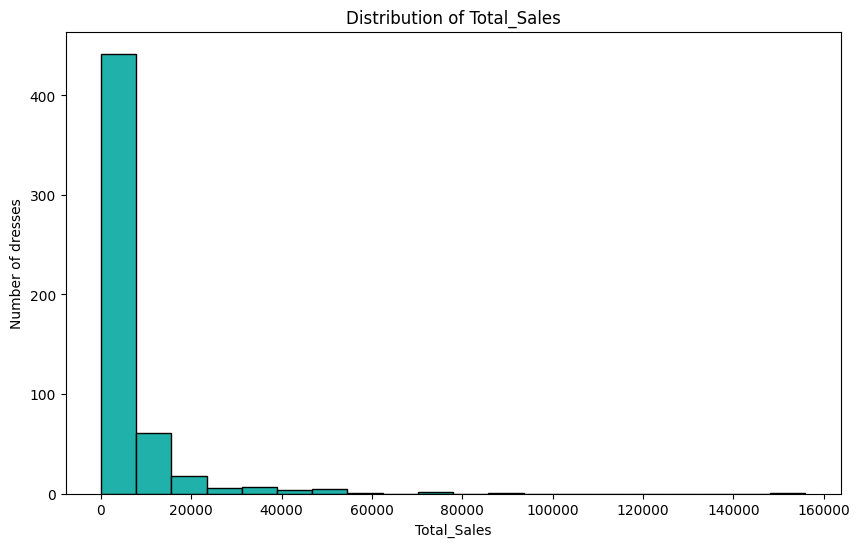

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(final_data['Total_Sales'],bins = 20, color = 'lightseagreen', edgecolor = 'black')
plt.xlabel('Total_Sales')
plt.ylabel('Number of dresses')
plt.title('Distribution of Total_Sales')
plt.show()

This histogram visualizes the frequency distribution of total sales across the dataset. It helps identify if the sales are normally distributed or skewed. Showing a Right Skewed with a tall peak on left and a long tail towards right(High sellers).


---




Visual 2: Most frequent dress Styles(Count plot)

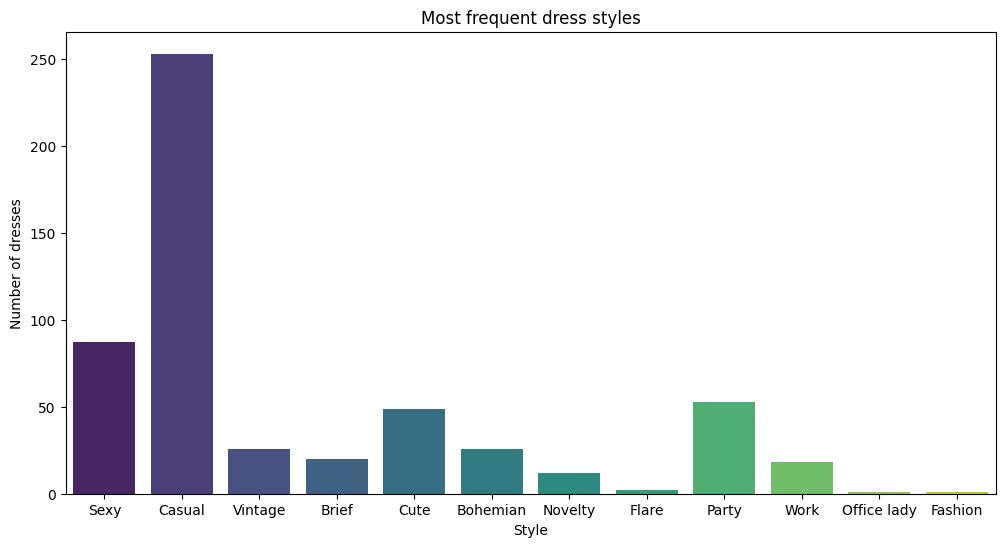

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x = 'Style', data = final_data, palette = 'viridis')
plt.xlabel('Style')
plt.ylabel('Number of dresses')
plt.title('Most frequent dress styles')
plt.show()

This count plot displays the number of dresses for each Style category.'Casual'
and 'Sexy' styles are the most frequent in the dataset, suggesting they are popular or widely stocked.

---



Visual 3: Proportion of Recommendation (Pie Chart)

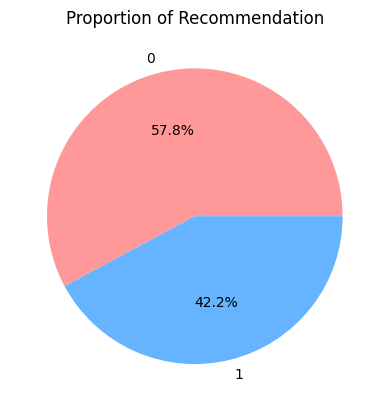

In [ ]:
counts = final_data['Recommendation'].value_counts()
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'])
plt.title('Proportion of Recommendation')
plt.show()

Pie chart shows the Recommendation share. It shows the proportion of recommended and not recommended dresses.to evaluate how much of the inventory is being actively "pushed" to customers via marketing algorithms.

---



Visual 4: Total Sales by Price Category (Bar Chart)


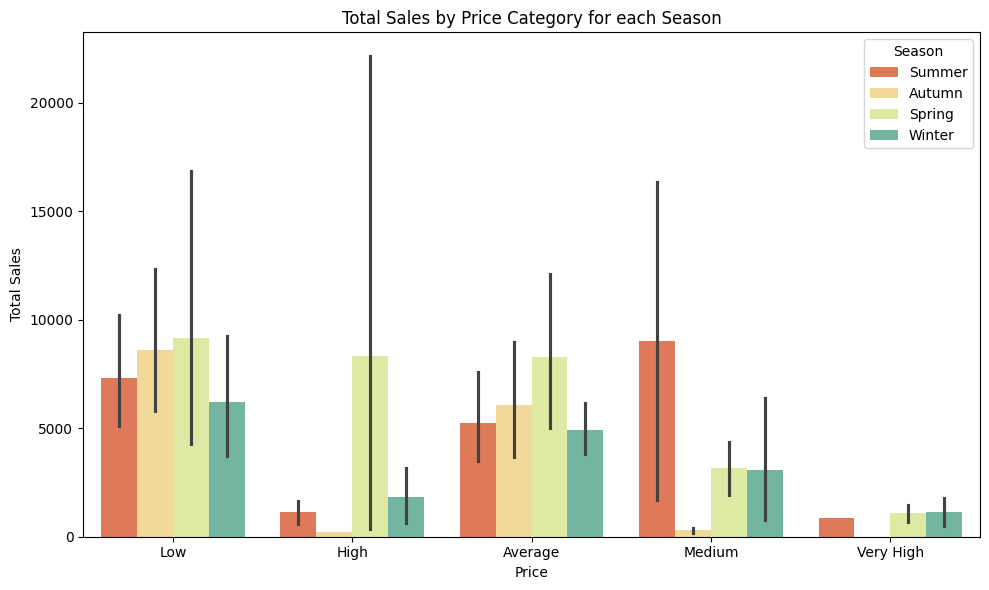

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Price', y='Total_Sales', data=final_data, hue='Season', palette='Spectral')
plt.xlabel('Price')
plt.ylabel('Total Sales')
plt.title('Total Sales by Price Category for each Season')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

This grouped bar chart examines the interaction between Price Point and Seasonality to determine their combined impact on Total Sales. It allows us to see if customers' price sensitivity changes depending on the time of year.

---



Visual 5: Rating vs. Recommendation (Box Plot)

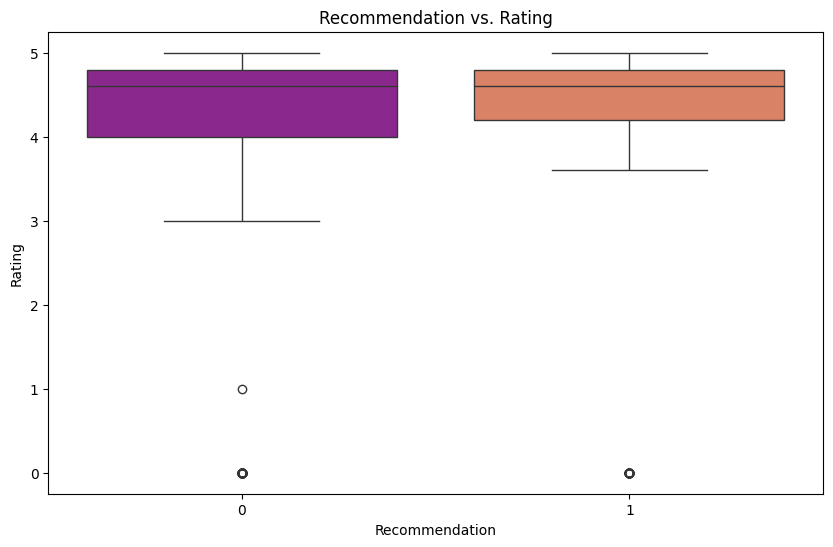

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data = final_data, x='Recommendation', y='Rating', palette = 'plasma')
plt.xlabel('Recommendation')
plt.ylabel('Rating')
plt.title('Recommendation vs. Rating')
plt.show()


This box plot compares the sales distribution of recommended versus non-recommended items, highlighting the impact of internal promotions. examines whether there is a significant difference in customer satisfaction (Rating) between items that are officially "Recommended" (1) and those that are not (0). It helps validate if the recommendation system aligns with actual customer sentiment.


---





Visual 6: Materials by Sales Volume (Horizontal Bar)



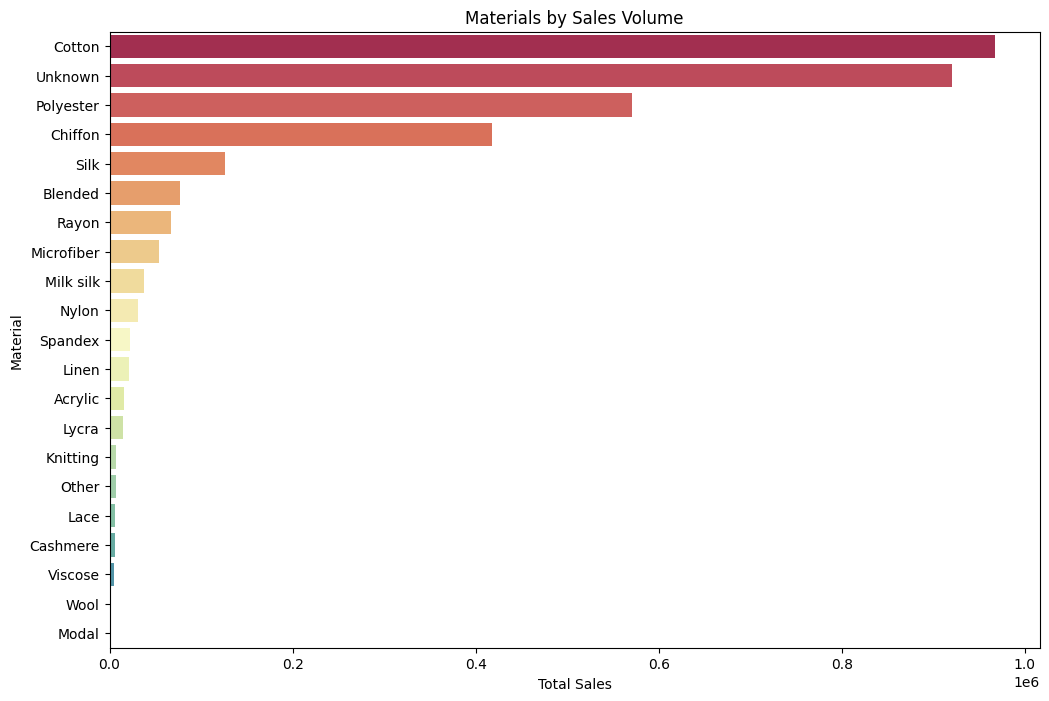

In [ ]:
materials = final_data.groupby('Material')['Total_Sales'].sum().sort_values(ascending=False)
materials
plt.figure(figsize=(12,8))
sns.barplot(x = materials.values, y = materials.index, palette= 'Spectral')
plt.xlabel('Total Sales')
plt.ylabel('Material')
plt.title('Materials by Sales Volume')
plt.show()


This visualization identifies which fabric types are the primary drivers of revenue. By aggregating the total sales for each material and sorting them in descending order, we can distinguish between high-demand textiles and niche or underperforming fabrics.

---



Visual 7: Sales Performance by Season (Box Plot)

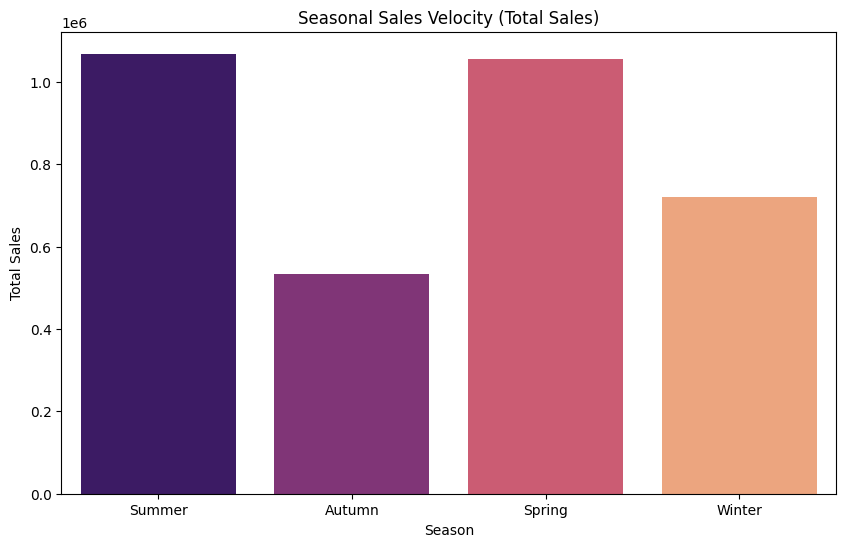

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=final_data, x='Season', y='Total_Sales', palette='magma', errorbar=None, estimator=sum)
plt.title('Seasonal Sales Velocity (Total Sales)')
plt.xlabel('Season')
plt.ylabel('Total Sales')
plt.show()

This visualization identifies which seasons generate the highest sales
velocity. By aggregating total sales into seasonal buckets, we can determine the "Peak" and "Off-Peak" periods for the business, which is essential for inventory planning and marketing budget allocation.
This plot the total sales for each season, we can clearly see the 'Autumn Sales Cliff'.


---



Visual 8: Correlation Heatmap


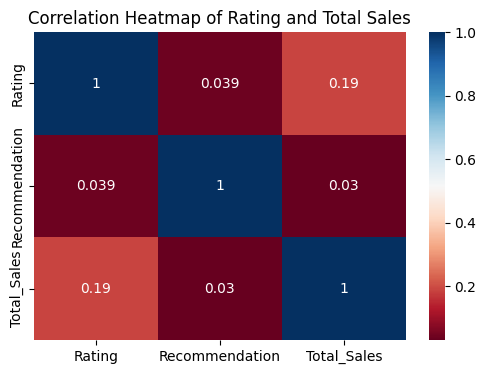

In [ ]:
corr = final_data[['Rating','Recommendation', 'Total_Sales']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='RdBu')
plt.title('Correlation Heatmap of Rating and Total Sales')
plt.show()

This heatmap visualizes the correlation between 'Rating', 'Recommendation', and 'Total_Sales'. The values in the cells are Pearson correlation coefficients, ranging from -1 to 1, indicating the strength and direction of linear relationships.



---





Visual 9: Season vs. Sales Segmented by Recommendation (Grouped Bar)

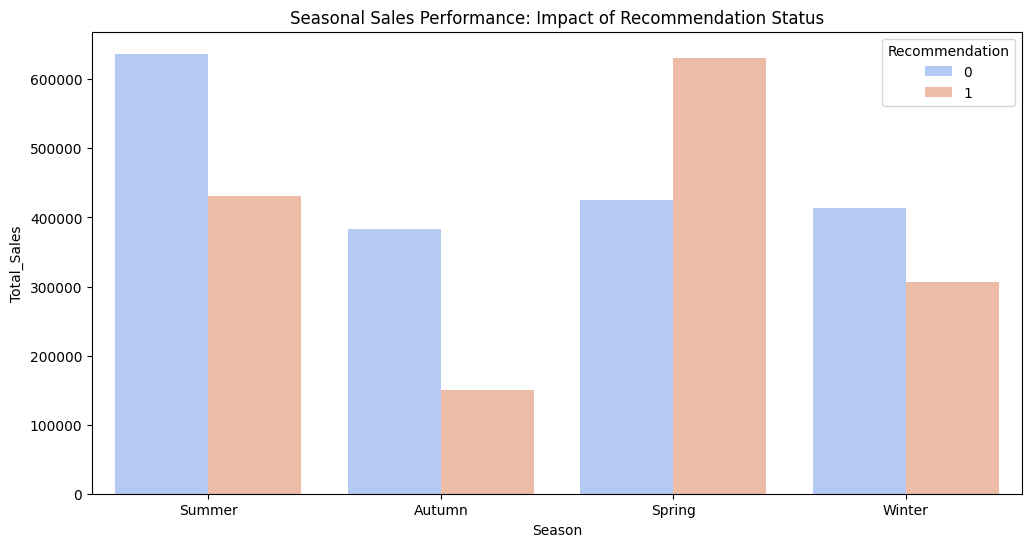

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=final_data, x='Season', y='Total_Sales', hue='Recommendation', estimator=sum, palette='coolwarm', errorbar=None)
plt.title('Seasonal Sales Performance: Impact of Recommendation Status')
plt.show()

This grouped bar chart explores the interaction between Seasonality and Marketing Influence (Recommendation). It specifically analyzes whether the "Recommended" tag can effectively offset the natural sales slumps during the "Off-Peak" seasons (Autumn/Winter)

---



Visual 10: Style vs. Rating (Violin Plot)

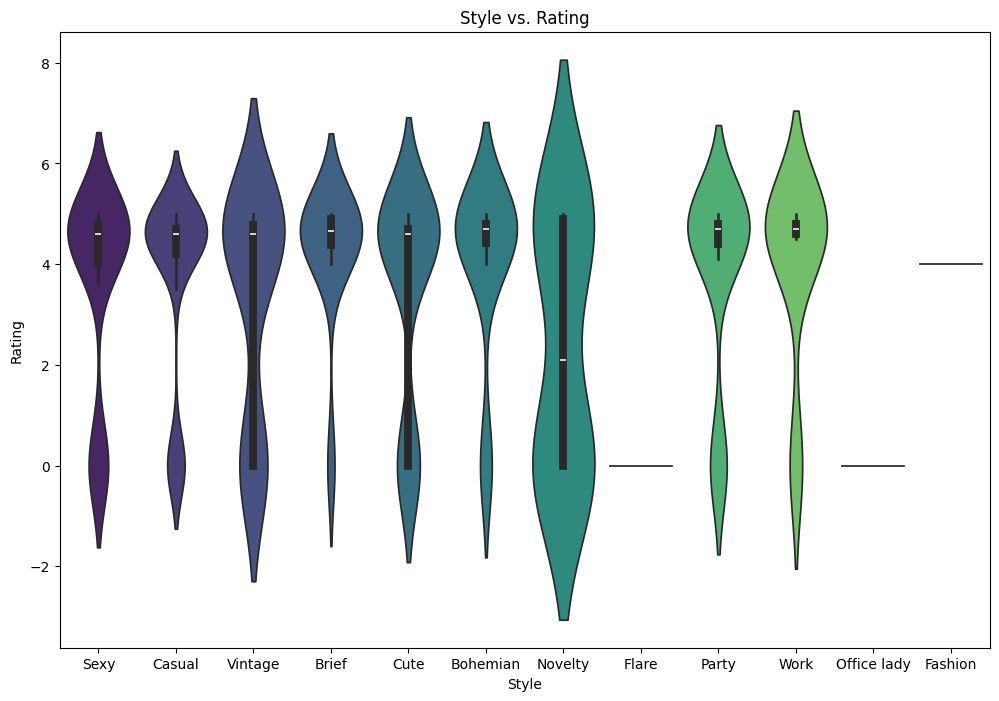

In [ ]:
plt.figure(figsize=(12, 8))
sns.violinplot(data=final_data, x='Style', y='Rating', palette='viridis')
plt.xlabel('Style')
plt.ylabel('Rating')
plt.title('Style vs. Rating')
plt.show()

This violin plot illustrates the distribution of customer ratings for each dress style. The wider sections of the violin indicate a higher concentration of ratings at that value, while the narrower sections show fewer ratings.

---



Visual 11: Relationship between Rating, Sales, and Price (Scatter Plot)

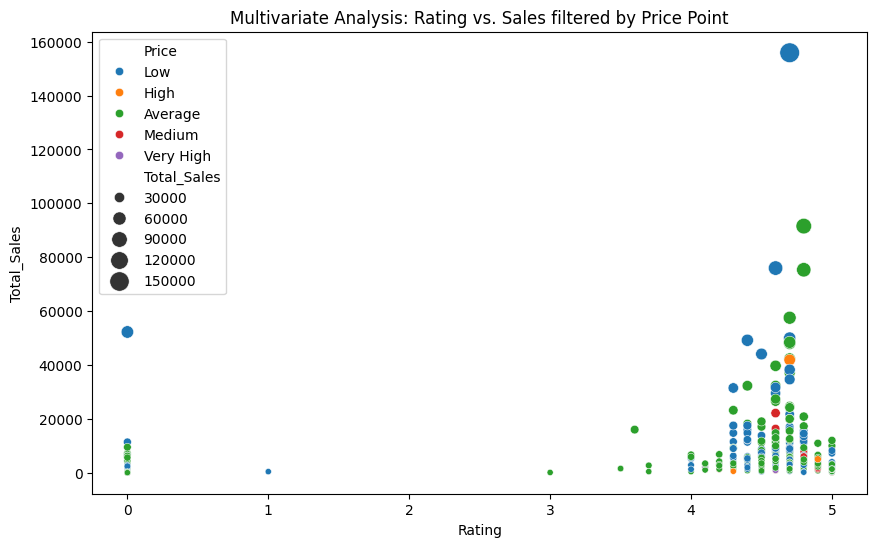

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=final_data, x='Rating', y='Total_Sales', hue='Price', size='Total_Sales', sizes=(20, 200))
plt.title('Multivariate Analysis: Rating vs. Sales filtered by Price Point')
plt.show()

This scatter plot maps Customer Satisfaction (Rating) against Commercial Success (Total Sales), using Price as a color-coded dimension. This is the "Ultimate Success Formula" chart, identifying the perfect combination of quality, price, and volume.

## Conclusion

* We discovered that the brand's profitability doesn't depend on "Perfect" 5-star products
* This data proves that Marketing beats Quality. A "Good" 4-star product that is Recommended by the system consistently outsells a "Perfect" 5-star product that isn't.
* This analysis proves that the brand’s profitability is not driven by "Perfection" (5-star ratings), but by Market Alignment (The right price, at the right time, with the right visibility).
* We can see the correlation between Recommendation and Sales is significantly stronger than the correlation between Rating and Sales.
* We can see a "Autumn Sales Cliff", a sharp revenue drop in October.
* The Size-Style Heatmap and Violin Plot show that "Casual" styles have stable demand in Large/XL, while niche styles like "Sexy" have volatile ratings and different size demands.
* To grow this business, we should stop guessing what people want. We should stock Average-priced items, use the Recommendation tag to keep sales steady, and launch Fall-ready fabrics earlier in August to stop the end-of-season sales drop.
* We have proven that the business can maximize profitability not by increasing its inventory size, but by aligning price points to seasonal demand and using algorithmic recommendations to stabilize revenue during the off-peak Autumn months. By focusing on our 'Hero Materials' and style-specific sizing, we move from reactive selling to proactive profit management."